# 1. Evaluate RAG Applications using RAG Triad

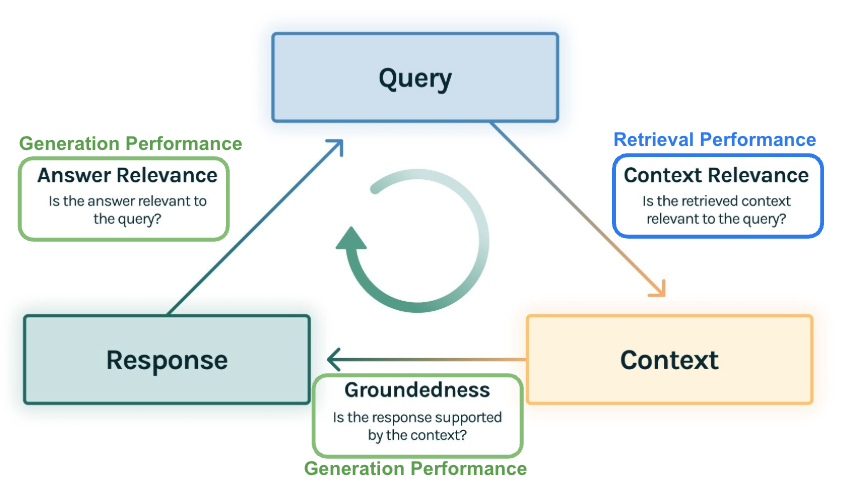

#### Source: https://truera.com/ai-quality-education/generative-ai-rags/what-is-the-rag-triad/

## a. Load Evaluation Dataset Comprising Input Questions for Evaluations.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Movies_Evaluation_input.csv')
df.head()

,user_input
0,What is Oppenheimer (film) about?
1,Who wrote and directed the film Oppenheimer?
2,What book is the film Oppenheimer based on and...
3,What are some key actors in the film Oppenheim...
4,When was Oppenheimer theatrically released in ...


## b. Connect Flowise Application in Colab

### Note: Expose Flowise Localhost to Google Colab (on cloud)


### **Important:** If you are running on Google Colab and your Flowise application is running locally on your computer or server, you will need to expose your localhost to Colab by tunneling.

**Steps to Connect Colab to Local Flowise:**

1. Run Flowise Locally: Ensure Flowise is running on your computer, typically via `npx flowise start`.
2. Expose Localhost to the Internet (Tunneling):
 - Install a tool like localtunnel: `npm install -g localtunnel`.
 - Run it on the Flowise port: `lt --port 3000`.
 - Copy the public URL generated (e.g., https://random-name.loca.lt).
3. Access from Colab: Use this public URL in your Colab notebook for API requests to Flowise.
- Replacing the front part of the original URL (http://localhost:3000/api/v1/prediction/YOUR_FLOW_ID")
- Final URL shd look like this: Example: requests.post("https://random-name.loca.lt/api/v1/prediction/YOUR_FLOW_ID", ...)


### What This Does
Google Colab runs on remote servers and cannot access `localhost` on your computer. **Localtunnel** creates a temporary public URL that forwards internet traffic to your local Flowise instance, allowing Colab to communicate with it.
```
Colab → https://random-name.loca.lt → Your Computer (port 3000) → Flowise
```

### Security Considerations
- **Public Exposure**: Your Flowise instance becomes temporarily accessible to anyone on the internet
- **No Authentication**: Unless configured, anyone with the URL can access your flows
- **Third-Party Routing**: Traffic passes through the tunnel service

### Why This Is Acceptable for This Workshop
- The tunnel is **temporary** and stops when you close the terminal
- We are using **non-sensitive test data** only
- This is a **controlled learning environment**, not a production setup
- Simply **shut down the tunnel** when you are done

**Note**: For production use cases, deploy Flowise to a proper cloud environment with authentication enabled.

### Change this example python code copied from Flowise from:

```
import requests

API_URL = "http://localhost:3001/api/v1/prediction/ff7c27f7-5329-4f8f-bc3b-b13345559f51"

def query(payload):
    response = requests.post(API_URL, json=payload)
    return response.json()
    
output = query({
    "question": "Hey, how are you?",
})

```

to:

```
import requests

API_URL = "https://random-name.loca.lt/api/v1/prediction/ff7c27f7-5329-4f8f-bc3b-b13345559f51"

def query(payload):
    response = requests.post(API_URL, json=payload)
    return response.json()
    
output = query({
    "question": "Hey, how are you?",
})
```

In [72]:
# The amended code looks like this:
import requests

API_URL = "https://clear-rocks-drum.loca.lt/api/v1/prediction/ff7c27f7-5329-4f8f-bc3b-b13345559f51"

def query(payload):
    response = requests.post(API_URL, json=payload)
    return response.json()

output = query({
    "question": "What is Oppenheimer (film) about?",
})

## c. Understand Output Structure (Optional Exercise on Details)

In [73]:
# View Flowise Output
print(output)

{'text': "Oppenheimer is a 2023 biographical drama film that chronicles the life of American theoretical physicist and polymath J. Robert Oppenheimer. The story predominantly focuses on Oppenheimer's early studies, his direction of the Manhattan Project during World War II, and his eventual fall from grace due to his 1954 security hearing. The film also explores Oppenheimer's relationship with Lewis Strauss, a senior member of the United States Atomic Energy Commission who sees Oppenheimer as a rival. The narrative is presented as a nonlinear story, highlighting key moments in Oppenheimer's life, including his scientific achievements, his moral dilemmas regarding nuclear weapons, and his political struggles during the Cold War era.", 'question': 'What is Oppenheimer (film) about?', 'chatId': 'b60ba14e-4643-4887-b574-e76c75cbe4bc', 'chatMessageId': '76b03263-82f5-4c8c-82c3-31c461c97b09', 'executionId': '1d1b1417-54f8-42d8-a71d-73b8141d82f7', 'agentFlowExecutedData': [{'nodeId': 'startAg

In [68]:
# Install library used to make json printout more readable
!pip install rich

In [74]:
# Use rich to print output
from rich.pretty import Pretty
from rich.console import Console

console = Console()
console.print(Pretty(output))

{
    'text': "Oppenheimer is a 2023 biographical drama film that chronicles the life of American theoretical 
physicist and polymath J. Robert Oppenheimer. The story predominantly focuses on Oppenheimer's early studies, his 
direction of the Manhattan Project during World War II, and his eventual fall from grace due to his 1954 security 
hearing. The film also explores Oppenheimer's relationship with Lewis Strauss, a senior member of the United States
Atomic Energy Commission who sees Oppenheimer as a rival. The narrative is presented as a nonlinear story, 
highlighting key moments in Oppenheimer's life, including his scientific achievements, his moral dilemmas regarding
nuclear weapons, and his political struggles during the Cold War era.",
    'question': 'What is Oppenheimer (film) about?',
    'chatId': 'b60ba14e-4643-4887-b574-e76c75cbe4bc',
    'chatMessageId': '76b03263-82f5-4c8c-82c3-31c461c97b09',
    'executionId': '1d1b1417-54f8-42d8-a71d-73b8141d82f7',
    'agentFlowExecutedData': [
        {
            'nodeId': 'startAgentflow_0',
            'nodeLabel': 'Start',
            'data': {
                'id': 'startAgentflow_0',
                'name': 'startAgentflow',
                'input': {'question': 'What is Oppenheimer (film) about?'},
                'output': {'question': 'What is Oppenheimer (film) about?'},
                'state': {}
            },
            'previousNodeIds': [],
            'status': 'FINISHED'
        },
        {
            'nodeId': 'retrieverAgentflow_0',
            'nodeLabel': 'Retriever 0',
            'data': {
                'id': 'retrieverAgentflow_0',
                'name': 'retrieverAgentflow',
                'input': {
                    'question': 'you are a smart retrieval who retrieves information from the knowledge base based 
on user question from What is Oppenheimer (film) about?'
                },
                'output': {
                    'content': '[\n  {\n    "pageContent": "Oppenheimer (film)\\nOppenheimer is a 2023 biographical
drama film written and directed by Christopher Nolan. Based \\non the 2005 biography American Prometheus by Kai 
Bird and Martin J. Sherwin, the film \\nchronicles the life of American theoretical physicist and polymath J. 
Robert Oppenheimer. The \\nstory predominantly focuses on Oppenheimer\'s early studies, his direction of the 
Manhattan Project \\nduring World War II, and his eventual fall from grace due to his 1954 security hearing; 
juxtaposed \\nwith this are events surrounding Oppenheimer\'s relationship with Lewis Strauss, a senior member 
\\nof the United States Atomic Energy Commission who sees Oppenheimer as a rival. It stars Cillian \\nMurphy as 
Oppenheimer and Robert Downey Jr. as Strauss, with the remaining ensemble \\nsupporting cast including Emily Blunt,
Matt Damon, Florence Pugh, Josh Hartnett, Casey Affleck, \\nRami Malek and Kenneth Branagh.\\nThe film was 
announced in September 2021 after Universal Pictures won a bidding war for Nolan\'s \\nscreenplay, following 
Nolan\'s conflict with longtime distributor Warner Bros. Pictures. Murphy was\\nthe first cast member to be signed 
on, to portray Oppenheimer in October, with others in the main \\ncast joining between November 2021 and April 
2022. Pre-production was underway by January \\n2022, with filming taking place from February to May. Oppenheimer 
was filmed in a combination \\nof IMAX 65 mm and 65 mm large-format film, including, for the first time in history,
sections in \\nIMAX black-and-white film photography. It is Nolan\'s first film to receive R-rating since Insomnia 
\\n(2002). Like his previous works, Nolan used extensive practical effects and minimal computer-\\ngenerated 
imagery.\\nOppenheimer premiered at Le Grand Rex in Paris on July 11, 2023, and was theatrically released in \\nthe
United States and United Kingdom on July 21, 2023, by Universal Pictures. Its simultaneous \\nrelease with Warner 
Bros.\' Barbie led to the \\"B

In [75]:
# Getting the response from the output
response = output['text']

response

"Oppenheimer is a 2023 biographical drama film that chronicles the life of American theoretical physicist and polymath J. Robert Oppenheimer. The story predominantly focuses on Oppenheimer's early studies, his direction of the Manhattan Project during World War II, and his eventual fall from grace due to his 1954 security hearing. The film also explores Oppenheimer's relationship with Lewis Strauss, a senior member of the United States Atomic Energy Commission who sees Oppenheimer as a rival. The narrative is presented as a nonlinear story, highlighting key moments in Oppenheimer's life, including his scientific achievements, his moral dilemmas regarding nuclear weapons, and his political struggles during the Cold War era."

In [76]:
# Getting the retrieved content (i.e. the retrieved chunks) from the output
retriever_content = output['agentFlowExecutedData'][1]['data']['output']['content']
print(type(retriever_content))
print(retriever_content)

<class 'str'>
[
  {
    "pageContent": "Oppenheimer (film)\nOppenheimer is a 2023 biographical drama film written and directed by Christopher Nolan. Based \non the 2005 biography American Prometheus by Kai Bird and Martin J. Sherwin, the film \nchronicles the life of American theoretical physicist and polymath J. Robert Oppenheimer. The \nstory predominantly focuses on Oppenheimer's early studies, his direction of the Manhattan Project \nduring World War II, and his eventual fall from grace due to his 1954 security hearing; juxtaposed \nwith this are events surrounding Oppenheimer's relationship with Lewis Strauss, a senior member \nof the United States Atomic Energy Commission who sees Oppenheimer as a rival. It stars Cillian \nMurphy as Oppenheimer and Robert Downey Jr. as Strauss, with the remaining ensemble \nsupporting cast including Emily Blunt, Matt Damon, Florence Pugh, Josh Hartnett, Casey Affleck, \nRami Malek and Kenneth Branagh.\nThe film was announced in September 2021 aft

In [77]:
# Formatting the retrieved content to make it easier to use in python
import json

# The retriever_content is already a string representation of a list of dictionaries
# We need to parse it to a Python object first
parsed_content = json.loads(retriever_content)

parsed_content[0]['pageContent']

# # Now, extract the 'pageContent' from each item in the list
# page_contents_only = [item['pageContent'] for item in parsed_content]

# # Print the extracted page content
# for content in page_contents_only:
#     print(content)


'Oppenheimer (film)\nOppenheimer is a 2023 biographical drama film written and directed by Christopher Nolan. Based \non the 2005 biography American Prometheus by Kai Bird and Martin J. Sherwin, the film \nchronicles the life of American theoretical physicist and polymath J. Robert Oppenheimer. The \nstory predominantly focuses on Oppenheimer\'s early studies, his direction of the Manhattan Project \nduring World War II, and his eventual fall from grace due to his 1954 security hearing; juxtaposed \nwith this are events surrounding Oppenheimer\'s relationship with Lewis Strauss, a senior member \nof the United States Atomic Energy Commission who sees Oppenheimer as a rival. It stars Cillian \nMurphy as Oppenheimer and Robert Downey Jr. as Strauss, with the remaining ensemble \nsupporting cast including Emily Blunt, Matt Damon, Florence Pugh, Josh Hartnett, Casey Affleck, \nRami Malek and Kenneth Branagh.\nThe film was announced in September 2021 after Universal Pictures won a bidding w

In [78]:
# Save all the chunks retrieved in a python list
retrieved_context = []

for n in range(len(parsed_content)):
  retrieved_context.append(parsed_content[n]['pageContent'])

retrieved_context

['Oppenheimer (film)\nOppenheimer is a 2023 biographical drama film written and directed by Christopher Nolan. Based \non the 2005 biography American Prometheus by Kai Bird and Martin J. Sherwin, the film \nchronicles the life of American theoretical physicist and polymath J. Robert Oppenheimer. The \nstory predominantly focuses on Oppenheimer\'s early studies, his direction of the Manhattan Project \nduring World War II, and his eventual fall from grace due to his 1954 security hearing; juxtaposed \nwith this are events surrounding Oppenheimer\'s relationship with Lewis Strauss, a senior member \nof the United States Atomic Energy Commission who sees Oppenheimer as a rival. It stars Cillian \nMurphy as Oppenheimer and Robert Downey Jr. as Strauss, with the remaining ensemble \nsupporting cast including Emily Blunt, Matt Damon, Florence Pugh, Josh Hartnett, Casey Affleck, \nRami Malek and Kenneth Branagh.\nThe film was announced in September 2021 after Universal Pictures won a bidding 

In [79]:
# Putting the input, retrieved chunks and the output response in a dataframe for easier usage later
eval_df = pd.DataFrame(columns=['input', 'retrieved_context', 'response'])
eval_df

eval_df.loc[len(eval_df.index)] = ['What is Oppenheimer (film) about?', retrieved_context, response]
eval_df

,input,retrieved_context,response
0,What is Oppenheimer (film) about?,[Oppenheimer (film)\nOppenheimer is a 2023 bio...,Oppenheimer is a 2023 biographical drama film ...


## d. Curate Evaluation Dataframe


In [80]:
# Load the CSV with all the input questions to be tested, iterate over the dataset using the Flowise application, save the retrieved chunks and final response of each question in a dataframe.

#Import json library
import json

# Load input query dataframe
source_df = pd.read_csv("/content/Movies_Evaluation_input.csv")

# Instantiate empty dataframe with the 'input', 'retrieved_context' and 'response' columns'
eval_df = pd.DataFrame(columns=['input', 'retrieved_context', 'response'])

# Iterate over the input query dataframe and get the chunks and response for each question. Each 'input', 'retrieved_context' and 'response' columns' triples saved in a new row
for i in range(len(source_df)):
  input = source_df['user_input'][i]

  output = query({
    "question": input,
  })

  retriever_content = output['agentFlowExecutedData'][1]['data']['output']['content']
  parsed_content = json.loads(retriever_content)
  retrieved_context = []

  for n in range(len(parsed_content)):
    retrieved_context.append(parsed_content[n]['pageContent'])

  response = output['text']
  eval_df.loc[len(eval_df.index)] = [input, retrieved_context, response]

eval_df

,input,retrieved_context,response
0,What is Oppenheimer (film) about?,[Oppenheimer (film)\nOppenheimer is a 2023 bio...,Oppenheimer is a 2023 biographical drama film ...
1,Who wrote and directed the film Oppenheimer?,[Oppenheimer (film)\nOppenheimer is a 2023 bio...,The film Oppenheimer was written and directed ...
2,What book is the film Oppenheimer based on and...,[Oppenheimer (film)\nOppenheimer is a 2023 bio...,The film Oppenheimer is based on the biography...
3,What are some key actors in the film Oppenheim...,[Oppenheimer (film)\nOppenheimer is a 2023 bio...,"Some key actors in the film ""Oppenheimer"" and ..."
4,When was Oppenheimer theatrically released in ...,[Oppenheimer (film)\nOppenheimer is a 2023 bio...,Oppenheimer was theatrically released in the U...
5,Who directed the film Barbie?,[Barbie (film)\nBarbie is a 2023 American fant...,The film Barbie was directed by Greta Gerwig.
6,Who wrote the screenplay for Barbie?,"[Entertainment, with Robbie's husband Tom Acke...",Greta Gerwig and Noah Baumbach wrote the scree...
7,Who plays the main characters Barbie and Ken i...,[unsuccessfully tries to convince Ken and the ...,"Margot Robbie plays Barbie, often referred to ..."
8,When did Barbie premiere and when was it theat...,"[On April 4, 2023, twenty-four character poste...",Barbie had its world premiere at the Shrine Au...
9,What cultural phenomenon occurred due to Barbi...,"[On April 4, 2023, twenty-four character poste...",The cultural phenomenon that occurred due to B...


## e. How to perform RAG Triad evaluation with Trulens Library

In [81]:
# Install the necessary libraries
!pip -q install trulens trulens-providers-openai python-dotenv==1.0.0

In [82]:
# Import environment packages:
from dotenv import load_dotenv
import os

# Load the .env file and the OpenAI API credentials
load_dotenv("/content/.env")
api_key = os.getenv("OPENAI_API_KEY")

In [83]:
query = "What are the benefits of green tea?"

context = [
    "Green tea contains antioxidants called catechins that help reduce cell damage and lower inflammation.",
    "Studies show green tea improves brain function and boosts metabolism due to its caffeine and L-theanine content.",
    "Green tea has been consumed in East Asia for centuries as a traditional beverage.",
]

response = "Green tea helps reduce cell damage through antioxidants and improves brain function due to caffeine and L-theanine."

In [84]:
from trulens.providers.openai import OpenAI
provider = OpenAI(model_engine="gpt-5-nano", api_key = api_key)  # or use your preferred model


In [86]:
provider.context_relevance(
    question=query,
    context=context,
)

0.6666666666666666

In [92]:
provider.context_relevance(
    question=query,
    context=context[0],
)

0.6666666666666666

In [93]:
provider.groundedness_measure_with_cot_reasons(
    source=context,
    statement=response,
)

(1.0,
 {'reasons': [{'criteria': 'Green tea helps reduce cell damage through antioxidants and improves brain function due to caffeine and L-theanine.',
    'supporting_evidence': 'Criteria: Green tea helps reduce cell damage through antioxidants and improves brain function due to caffeine and L-theanine.\nSupporting Evidence: Green tea contains antioxidants called catechins that help reduce cell damage and lower inflammation. Studies show green tea improves brain function and boosts metabolism due to its caffeine and L-theanine content.',
    'score': 1.0}]})

In [97]:
provider.groundedness_measure_with_cot_reasons(
    source=context[0],
    statement=response,
)

(0.6666666666666666,
 {'reasons': [{'criteria': 'Green tea helps reduce cell damage through antioxidants and improves brain function due to caffeine and L-theanine.',
    'supporting_evidence': 'Criteria: Green tea helps reduce cell damage through antioxidants and improves brain function due to caffeine and L-theanine.\nSupporting Evidence: Green tea contains antioxidants called catechins that help reduce cell damage and lower inflammation.',
    'score': 0.6666666666666666}]})

In [85]:
provider.relevance(
    prompt=query,
    response=response,
)

(0.6666666666666666,
 {'reason': {'criteria': 'The response is relevant to the prompt by listing specific benefits of green tea, but it does not exhaustively cover all common benefits, so it is not a complete answer.',
   'supporting_evidence': "The response states two benefits: 'reduces cell damage through antioxidants' and 'improves brain function due to caffeine and L-theanine,' showing relevance to the prompt; however, it does not mention other widely cited benefits like metabolism or cardiovascular effects.",
   'score': 2}})

In [98]:
query = "What are the health benefits of green tea?"

# --- Example 1: Good RAG ---
print("=== GOOD RAG ===")

good_context = [
    "Green tea contains antioxidants called catechins that help reduce cell damage and lower inflammation.",
    "Studies show green tea improves brain function and boosts metabolism due to its caffeine and L-theanine content.",
    "Green tea has been consumed in East Asia for centuries as a traditional beverage.",
]

good_response = "Green tea helps reduce cell damage through antioxidants and improves brain function due to caffeine and L-theanine."

for chunk in good_context:
    result = provider.context_relevance(question=query, context=chunk)
    score = result[0] if isinstance(result, tuple) else result
    print(f"CR: {score:.2f} | {chunk[:60]}...")

result = provider.groundedness_measure_with_cot_reasons(source="\n".join(good_context), statement=good_response)
print(f"Groundedness: {result[0]:.2f}")

result = provider.relevance(prompt=query, response=good_response)
score = result[0] if isinstance(result, tuple) else result
print(f"Answer Relevance: {score:.2f}")

# --- Example 2: Bad RAG ---
print("\n=== BAD RAG ===")

bad_context = [
    "Green tea contains antioxidants called catechins that help reduce cell damage and lower inflammation.",
    "The FIFA World Cup is held every four years and attracts millions of viewers worldwide.",
    "Python is a popular programming language used in data science and web development.",
]

bad_response = "The process of photosynthesis converts sunlight into chemical energy in plant cells."

for chunk in bad_context:
    result = provider.context_relevance(question=query, context=chunk)
    score = result[0] if isinstance(result, tuple) else result
    print(f"CR: {score:.2f} | {chunk[:60]}...")

result = provider.groundedness_measure_with_cot_reasons(source="\n".join(bad_context), statement=bad_response)
print(f"Groundedness: {result[0]:.2f}")

result = provider.relevance(prompt=query, response=bad_response)
score = result[0] if isinstance(result, tuple) else result
print(f"Answer Relevance: {score:.2f}")

=== GOOD RAG ===
CR: 0.67 | Green tea contains antioxidants called catechins that help r...
CR: 0.67 | Studies show green tea improves brain function and boosts me...
CR: 0.00 | Green tea has been consumed in East Asia for centuries as a ...
Groundedness: 1.00
Answer Relevance: 0.67

=== BAD RAG ===
CR: 0.67 | Green tea contains antioxidants called catechins that help r...
CR: 0.00 | The FIFA World Cup is held every four years and attracts mil...
CR: 0.00 | Python is a popular programming language used in data scienc...
Groundedness: 0.00
Answer Relevance: 0.00


## f. Evaluate over the eval_df using RAG Triad Metrics

### Evaluating RAG Systems: Single-Call vs Per-Chunk Approach

When evaluating a RAG system using the RAG Triad (Context Relevance, Groundedness, Answer Relevance), you need to decide **how** to handle the multiple context chunks returned by your retriever. There are two main approaches.

### Single-Call Approach

In the Single-Call approach, all retrieved context chunks are combined into a single string and passed to the LLM judge in **one go**. The LLM receives everything together and returns a single score.

```python
# Combine all chunks into one string
combined_context = "\n".join(context) if isinstance(context, list) else context

# One call, one score
score = provider.context_relevance(question=query, context=combined_context)
```

This is simpler and cheaper, but it treats all the context as a single blob. You cannot tell which specific chunk scored well or poorly.

### Per-Chunk Approach

In the Per-Chunk approach, each retrieved chunk is evaluated **individually** in a separate LLM call. The individual scores are then combined using an aggregation function (e.g., `np.mean` or `np.max`).

```python
# Evaluate each chunk separately
chunk_scores = []
for chunk in chunks:
    score = provider.context_relevance(question=query, context=chunk)
    chunk_scores.append(score)

# Aggregate the individual scores
final_score = np.mean(chunk_scores)
```

This gives you **granular visibility** into each chunk's contribution. If your retriever pulls in 3 relevant chunks and 2 irrelevant ones, you can see exactly which ones are dragging the score down.

### Comparison

| | Single-Call Approach | Per-Chunk Approach |
|---|---|---|
| How it works | Combines all context into one string, passes to LLM in one call | Loops through each chunk, one LLM call per chunk, then aggregates |
| Context Relevance | 1 LLM call → 1 score | 5 chunks → 5 LLM calls → 5 scores → `np.mean` |
| Groundedness | 1 LLM call → 1 score | 5 chunks → 5 LLM calls → 5 scores → `np.max` |
| Answer Relevance | 1 LLM call → 1 score (same for both — only compares query vs response) | |
| Pros | Faster, fewer API calls, cheaper | More granular, can identify weak chunks, more accurate scoring |
| Cons | Can't pinpoint which chunk is problematic | Slower, more API calls, more expensive |

### Choosing an Aggregation Function (Per-Chunk)

When using the Per-Chunk approach, the choice of aggregation function matters:

- **`np.mean` (average)** — Best for **Context Relevance**. It reflects overall retrieval quality. If 3 out of 5 chunks are irrelevant, the mean will reflect that mixed quality, signaling that your retriever needs improvement.

- **`np.max` (maximum)** — Best for **Groundedness**. The response only needs to be supported by at least one chunk. A single highly-supportive chunk is enough to ground the answer, even if the other chunks are unrelated.

### A Note on TruLens' `Feedback()` Wrapper

You may see TruLens examples that define feedback functions like this:

```python
f_context_relevance = (
    Feedback(provider.context_relevance)
    .on_input()
    .on_context(collect_list=False)
    .aggregate(np.mean)
)
```

The selectors (`.on_input()`, `.on_context()`, `.aggregate()`) are **data mapping instructions** that only activate during TruLens app recording (e.g., with `TruLlama`, `TruChain`, or `TruApp`). If you call `f_context_relevance(query, context)` directly, the selectors are ignored — the entire context list is passed as-is in a single LLM call.

That is why both approaches in this guide call the `provider` methods directly (e.g., `provider.context_relevance(...)`) instead of using the `Feedback()` wrapper.

### When to Use Which

- Use the **Single-Call approach** for quick prototyping or when API costs are a concern.
- Use the **Per-Chunk approach** when you need detailed diagnostics to improve your retriever or when evaluation accuracy is more important than speed.


### Single-Call Approach

In [99]:
# Single-Call Approach
# All context chunks are passed to the LLM judge in one call per metric.
# Simpler and cheaper, but less granular than the Per-Chunk Approach.

import pandas as pd
import numpy as np
from trulens.providers.openai import OpenAI
import time

# Initialize the LLM provider for evaluation
provider = OpenAI(model_engine="gpt-5-nano", api_key=api_key)

# Load your CSV data into a pandas DataFrame
df = eval_df

# This list will store the evaluation results for each row of your data.
results = []

for idx, row in df.iterrows():
    query = row["input"]
    context = row["retrieved_context"]  # Can be a list of chunks or a string
    response = row["response"]

    # Combine context chunks into a single string if it's a list
    combined_context = "\n".join(context) if isinstance(context, list) else context

    # Initialize scores to NaN (if an evaluation fails, it stays NaN)
    context_relevance_score = np.nan
    groundedness_score = np.nan
    answer_relevance_score = np.nan

    # --- Context Relevance ---
    # How relevant is the retrieved context to the user's question?
    try:
        result = provider.context_relevance(question=query, context=combined_context)
        context_relevance_score = result[0] if isinstance(result, tuple) else result
    except Exception as e:
        print(f"Error computing context relevance for row {idx + 1}: {e}")

    # --- Groundedness ---
    # Is the generated answer supported by the retrieved context?
    try:
        result = provider.groundedness_measure_with_cot_reasons(
            source=combined_context,
            statement=response
        )
        groundedness_score = result[0] if isinstance(result, tuple) else result
    except Exception as e:
        print(f"Error computing groundedness for row {idx + 1}: {e}")

    # --- Answer Relevance ---
    # How relevant is the generated answer to the original question?
    try:
        result = provider.relevance(prompt=query, response=response)
        answer_relevance_score = result[0] if isinstance(result, tuple) else result
    except Exception as e:
        print(f"Error computing answer relevance for row {idx + 1}: {e}")

    results.append({
        "input": query,
        "context_relevance": context_relevance_score,
        "groundedness": groundedness_score,
        "answer_relevance": answer_relevance_score
    })

    print(f"Row {idx + 1}: CR={context_relevance_score:.2f}, G={groundedness_score:.2f}, AR={answer_relevance_score:.2f}")
    time.sleep(1)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Add average row at the end
average_row = {
    "input": "AVERAGE",
    "context_relevance": results_df["context_relevance"].mean(),
    "groundedness": results_df["groundedness"].mean(),
    "answer_relevance": results_df["answer_relevance"].mean()
}
results_df = pd.concat([results_df, pd.DataFrame([average_row])], ignore_index=True)

# Save to CSV
results_df.to_csv("evaluation_results.csv", index=False)

print(f"\n--- AVERAGES ---")
print(f"Context Relevance: {average_row['context_relevance']:.2f}")
print(f"Groundedness: {average_row['groundedness']:.2f}")
print(f"Answer Relevance: {average_row['answer_relevance']:.2f}")
print("\nEvaluation complete! Results saved to evaluation_results.csv")

Row 1: CR=1.00, G=1.00, AR=1.00
Row 2: CR=1.00, G=1.00, AR=1.00
Row 3: CR=1.00, G=1.00, AR=1.00
Row 4: CR=0.67, G=1.00, AR=0.67
Row 5: CR=1.00, G=1.00, AR=1.00
Row 6: CR=1.00, G=1.00, AR=1.00
Row 7: CR=1.00, G=1.00, AR=1.00
Row 8: CR=1.00, G=1.00, AR=1.00
Row 9: CR=1.00, G=1.00, AR=1.00
Row 10: CR=1.00, G=1.00, AR=1.00

--- AVERAGES ---
Context Relevance: 0.97
Groundedness: 1.00
Answer Relevance: 0.97

Evaluation complete! Results saved to evaluation_results.csv


### Per-Chunk Approach

In [100]:
# Per-Chunk Approach
# Each context chunk is evaluated individually by the LLM judge, then aggregated.
# More granular and accurate, but slower and more expensive than the Single-Call Approach.

import pandas as pd
import numpy as np
from trulens.providers.openai import OpenAI
import time

# Initialize the LLM provider for evaluation
provider = OpenAI(model_engine="gpt-5-nano", api_key=api_key)

# Load your CSV data into a pandas DataFrame
df = eval_df

# This list will store the evaluation results for each row of your data.
results = []

for idx, row in df.iterrows():
    query = row["input"]
    context = row["retrieved_context"]  # Can be a list of chunks or a string
    response = row["response"]

    # Ensure context is a list for consistent iteration
    chunks = context if isinstance(context, list) else [context]

    # Initialize scores to NaN (if an evaluation fails, it stays NaN)
    context_relevance_score = np.nan
    groundedness_score = np.nan
    answer_relevance_score = np.nan

    # --- Context Relevance ---
    # How relevant is each retrieved chunk to the user's question?
    # Each chunk is scored separately, then averaged.
    try:
        chunk_scores = []
        for chunk in chunks:
            result = provider.context_relevance(question=query, context=chunk)
            score = result[0] if isinstance(result, tuple) else result
            chunk_scores.append(score)
        context_relevance_score = np.mean(chunk_scores)
    except Exception as e:
        print(f"Error computing context relevance for row {idx + 1}: {e}")

    # --- Groundedness ---
    # Is the generated answer supported by each retrieved chunk?
    # Each chunk is scored separately, then we take the max.
    try:
        chunk_scores = []
        for chunk in chunks:
            result = provider.groundedness_measure_with_cot_reasons(
                source=chunk,
                statement=response
            )
            score = result[0] if isinstance(result, tuple) else result
            chunk_scores.append(score)
        groundedness_score = np.max(chunk_scores)
    except Exception as e:
        print(f"Error computing groundedness for row {idx + 1}: {e}")

    # --- Answer Relevance ---
    # How relevant is the generated answer to the original question?
    # (No per-chunk needed — this only compares query vs response)
    try:
        result = provider.relevance(prompt=query, response=response)
        answer_relevance_score = result[0] if isinstance(result, tuple) else result
    except Exception as e:
        print(f"Error computing answer relevance for row {idx + 1}: {e}")

    results.append({
        "input": query,
        "context_relevance": context_relevance_score,
        "groundedness": groundedness_score,
        "answer_relevance": answer_relevance_score
    })

    print(f"Row {idx + 1}: CR={context_relevance_score:.2f}, G={groundedness_score:.2f}, AR={answer_relevance_score:.2f}")
    time.sleep(1)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Add average row at the end
average_row = {
    "input": "AVERAGE",
    "context_relevance": results_df["context_relevance"].mean(),
    "groundedness": results_df["groundedness"].mean(),
    "answer_relevance": results_df["answer_relevance"].mean()
}
results_df = pd.concat([results_df, pd.DataFrame([average_row])], ignore_index=True)

# Save to CSV
results_df.to_csv("evaluation_results.csv", index=False)

print(f"\n--- AVERAGES ---")
print(f"Context Relevance: {average_row['context_relevance']:.2f}")
print(f"Groundedness: {average_row['groundedness']:.2f}")
print(f"Answer Relevance: {average_row['answer_relevance']:.2f}")
print("\nEvaluation complete! Results saved to evaluation_results.csv")

Row 1: CR=0.75, G=0.92, AR=1.00
Row 2: CR=0.67, G=1.00, AR=1.00
Row 3: CR=0.50, G=1.00, AR=1.00
Row 4: CR=0.33, G=1.00, AR=0.67
Row 5: CR=0.58, G=1.00, AR=1.00
Row 6: CR=0.75, G=1.00, AR=1.00
Row 7: CR=0.67, G=1.00, AR=1.00
Row 8: CR=0.83, G=1.00, AR=1.00
Row 9: CR=0.67, G=1.00, AR=1.00


/usr/local/lib/python3.12/dist-packages/trulens/feedback/llm_provider.py:2717: UserWarning: Failed to process and remove trivial statements. Proceeding with all statements.
  warnings.warn(


Row 10: CR=0.75, G=1.00, AR=1.00

--- AVERAGES ---
Context Relevance: 0.65
Groundedness: 0.99
Answer Relevance: 0.97

Evaluation complete! Results saved to evaluation_results.csv


# 2. Evaluate using LLM as a Judge

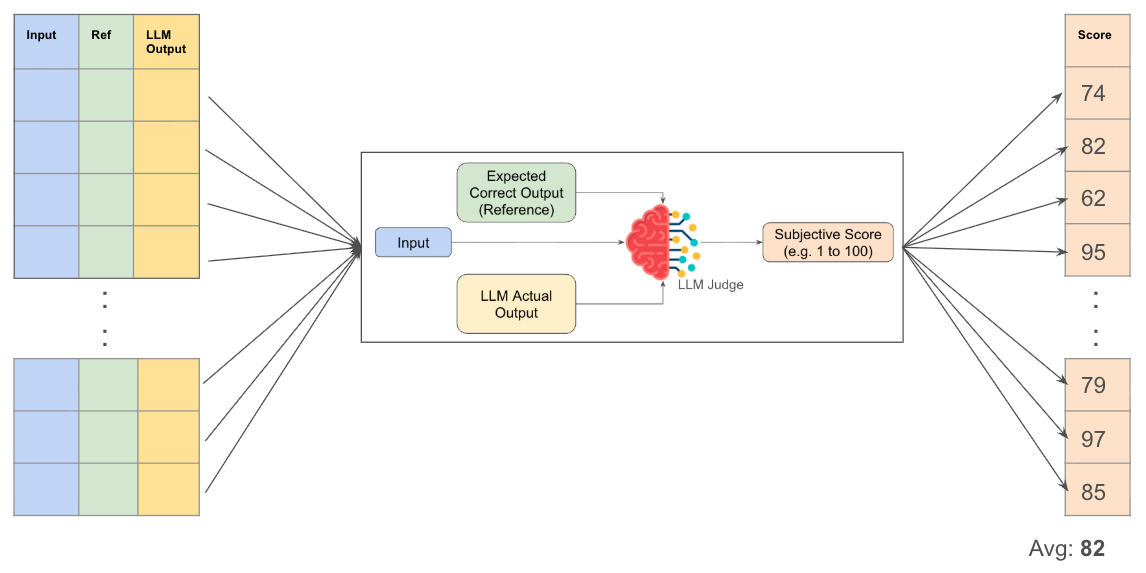

## a. Load Evaluation Dataset Comprising Input Questions and Reference Answers for Evaluations.

In [64]:
# Preview the dataframe loaded. This dataframe will be used for evluating the LLM output.
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Movies_Evaluation_input_n_reference.csv')
df.head()

,user_input,reference
0,What is Oppenheimer (film) about?,Oppenheimer is a 2023 biographical drama film ...
1,Who wrote and directed the film Oppenheimer?,The film Oppenheimer was written and directed ...
2,What book is the film Oppenheimer based on and...,The film Oppenheimer is based on the 2005 biog...
3,What are some key actors in the film Oppenheim...,Key actors include Cillian Murphy as Oppenheim...
4,When was Oppenheimer theatrically released in ...,Oppenheimer was theatrically released in the U...


## b. Connect Flowise Application in Colab

In [63]:
# This is the same as 1(b) above. The amended code looks like this:
import requests

# For use in Colab, we need to replace the localhost URL from API_URL "http://localhost:3000/api/v1/prediction/YOUR_FLOW_ID" from the localtunnel tool to the below:
API_URL = "https://puny-rice-fix.loca.lt/api/v1/prediction/ff7c27f7-5329-4f8f-bc3b-b13345559f51"

def query(payload):
    response = requests.post(API_URL, json=payload)
    return response.json()

output = query({
    "question": "What is Oppenheimer (film) about?",
})

## c. Curate Evaluation Dataframe

In [65]:
# Load the CSV with all the input questions to be tested, iterate over the dataset using the Flowise application, save the retrieved chunks and final response of each question in a dataframe.

# Load input query dataframe
source_df = pd.read_csv("/content/Movies_Evaluation_input_n_reference.csv")

# Instantiate empty dataframe with the 'input', 'retrieved_context' and 'response' columns'
llm_judge_eval_df = pd.DataFrame(columns=['input', 'reference', 'response'])

# Iterate over the input query dataframe and get the chunks and response for each question. Each 'input', 'retrieved_context' and 'response' columns' triples saved in a new row
for i in range(len(source_df)):
  input = source_df['user_input'][i]
  reference = source_df['reference'][i]

  output = query({
    "question": input,
  })

  response = output['text']
  llm_judge_eval_df.loc[len(llm_judge_eval_df.index)] = [input, reference, response]

llm_judge_eval_df

,input,reference,response
0,What is Oppenheimer (film) about?,Oppenheimer is a 2023 biographical drama film ...,Oppenheimer is a 2023 biographical drama film ...
1,Who wrote and directed the film Oppenheimer?,The film Oppenheimer was written and directed ...,"The film ""Oppenheimer"" was written and directe..."
2,What book is the film Oppenheimer based on and...,The film Oppenheimer is based on the 2005 biog...,The film Oppenheimer is based on the biography...
3,What are some key actors in the film Oppenheim...,Key actors include Cillian Murphy as Oppenheim...,"Some key actors in the film ""Oppenheimer"" and ..."
4,When was Oppenheimer theatrically released in ...,Oppenheimer was theatrically released in the U...,Oppenheimer was theatrically released in the U...
5,Who directed the film Barbie?,Barbie was directed by Greta Gerwig.,The film Barbie was directed by Greta Gerwig.
6,Who wrote the screenplay for Barbie?,Greta Gerwig and Noah Baumbach wrote the scree...,Greta Gerwig and Noah Baumbach wrote the scree...
7,Who plays the main characters Barbie and Ken i...,Margot Robbie stars as the titular character B...,"Margot Robbie plays Barbie, often referred to ..."
8,When did Barbie premiere and when was it theat...,Barbie premiered at the Shrine Auditorium in L...,Barbie had its world premiere at the Shrine Au...
9,What cultural phenomenon occurred due to Barbi...,Its simultaneous release with Universal's Oppe...,The cultural phenomenon that occurred due to B...


## d. How to perform RAG evaluation with LLM-As-A-Judge

In [66]:
# Use LLM-As-A-Judge to evaluate the LLM response against a reference answer

import pandas as pd
import numpy as np
import re
from openai import OpenAI
import time

# Initialize OpenAI provider with the specified model and API key
client = OpenAI()

# Prepare DataFrame for evaluation results
llm_eval_results = pd.DataFrame(columns=['input', 'reference', 'response', 'llm_judge_score'])

for idx, row in llm_judge_eval_df.iterrows():
    user_input = row['input']
    reference = row['reference']
    llm_actual_output = row['response']

    # Construct the custom prompt for the LLM judge
    eval_prompt = (
        f"Given the input \"{user_input}\" and reference output \"{reference}\", "
        f"score the model response \"{llm_actual_output}\" on a scale of 0 to 100, "
        "where 100 is the best score. Respond with the number only"
    )

    score = np.nan
    try:
        # Call the LLM to get the score using generate_text
        response = client.responses.create(
          model="gpt-5-nano",
          instructions=eval_prompt,
          input=user_input
        )

        llm_response_text = response.output_text

        # Extract the number from the LLM's response
        # Use regex to find any sequence of digits, then convert to float
        match = re.search(r'\d+', llm_response_text)
        if match:
            score = float(match.group(0))
        else:
            print(f"Could not parse score from LLM response for row {idx + 1}: {llm_response_text}")

    except Exception as e:
        print(f"Error during LLM evaluation for row {idx + 1}: {e}")

    # Append results to the DataFrame
    llm_eval_results.loc[len(llm_eval_results)] = [
        user_input,
        reference,
        llm_actual_output,
        score
    ]

    print(f"Row {idx + 1}: Score = {score:.2f}")
    time.sleep(1) # Add a small delay to prevent rate limiting

# Add average row at the end
average_score = llm_eval_results['llm_judge_score'].mean()
average_row = pd.DataFrame([{
    'input': "AVERAGE",
    'reference': "",
    'response': "",
    'llm_judge_score': average_score
}])
llm_eval_results = pd.concat([llm_eval_results, average_row], ignore_index=True)

display(llm_eval_results)
print(f"\nAverage LLM-as-a-Judge Score: {average_score:.2f}")

llm_eval_results.to_csv('llm_judge_evaluation_results.csv', index=False)
print('LLM-as-a-Judge evaluation results saved to llm_judge_evaluation_results.csv')

Row 1: Score = 89.00
Row 2: Score = 95.00
Row 3: Score = 95.00
Row 4: Score = 60.00
Row 5: Score = 100.00
Row 6: Score = 100.00
Row 7: Score = 100.00
Row 8: Score = 95.00
Row 9: Score = 100.00
Row 10: Score = 95.00


,input,reference,response,llm_judge_score
0,What is Oppenheimer (film) about?,Oppenheimer is a 2023 biographical drama film ...,Oppenheimer is a 2023 biographical drama film ...,89.0
1,Who wrote and directed the film Oppenheimer?,The film Oppenheimer was written and directed ...,"The film ""Oppenheimer"" was written and directe...",95.0
2,What book is the film Oppenheimer based on and...,The film Oppenheimer is based on the 2005 biog...,The film Oppenheimer is based on the biography...,95.0
3,What are some key actors in the film Oppenheim...,Key actors include Cillian Murphy as Oppenheim...,"Some key actors in the film ""Oppenheimer"" and ...",60.0
4,When was Oppenheimer theatrically released in ...,Oppenheimer was theatrically released in the U...,Oppenheimer was theatrically released in the U...,100.0
5,Who directed the film Barbie?,Barbie was directed by Greta Gerwig.,The film Barbie was directed by Greta Gerwig.,100.0
6,Who wrote the screenplay for Barbie?,Greta Gerwig and Noah Baumbach wrote the scree...,Greta Gerwig and Noah Baumbach wrote the scree...,100.0
7,Who plays the main characters Barbie and Ken i...,Margot Robbie stars as the titular character B...,"Margot Robbie plays Barbie, often referred to ...",95.0
8,When did Barbie premiere and when was it theat...,Barbie premiered at the Shrine Auditorium in L...,Barbie had its world premiere at the Shrine Au...,100.0
9,What cultural phenomenon occurred due to Barbi...,Its simultaneous release with Universal's Oppe...,The cultural phenomenon that occurred due to B...,95.0



Average LLM-as-a-Judge Score: 92.90
LLM-as-a-Judge evaluation results saved to llm_judge_evaluation_results.csv
